In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

In [3]:
# Input directory (update this path as needed)
DIR = Path("./Revision_code/Fig7a/")

# Input file: pairwise evaluation results
input_file = DIR / "all_results.txt"

In [4]:
# Load the result table
df = pd.read_csv(input_file, sep=r"\s+", header=None, names=["pair", "ACC", "AUC", "F1"])

# Remove trailing "_r" from labels
df["pair"] = df["pair"].str.replace("_r", "", regex=False)

# Split "A_vs_B" into two columns A and B
df[["A", "B"]] = df["pair"].str.split("vs", expand=True)


In [5]:
# 1. Exclude any comparisons that involve "Cancer"
df = df[(df["A"] != "Cancer") & (df["B"] != "Cancer")]

# 2. Define the order of cell types (custom)
cells = [
    "ESC", "iPSC", "ESderived",
    "bloodTcell", "HSCBcell",
    "Brain", "Muscle", "Heart", "SmoothMuscle"
]

# Convert to Categorical so the heatmaps respect the ordering
df["A"] = pd.Categorical(df["A"], categories=cells, ordered=True)
df["B"] = pd.Categorical(df["B"], categories=cells, ordered=True)

samples = cells


In [6]:
# Directory for saving all figures
outdir = DIR / "Fig7a"
outdir.mkdir(exist_ok=True)


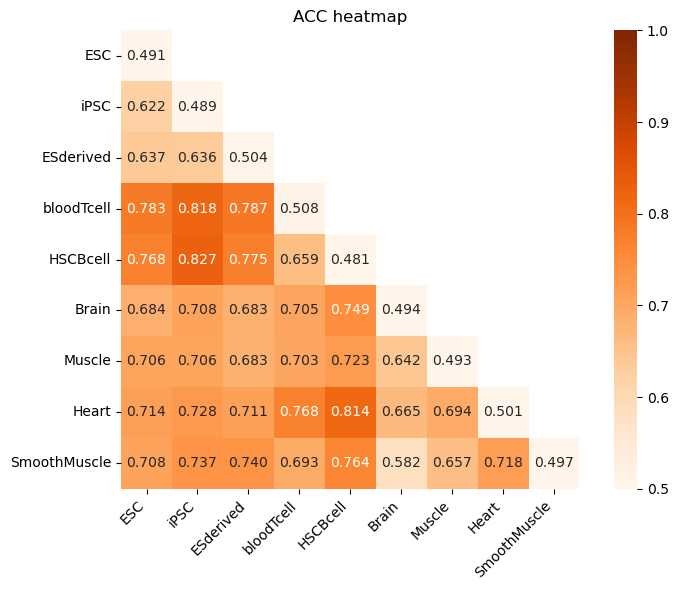

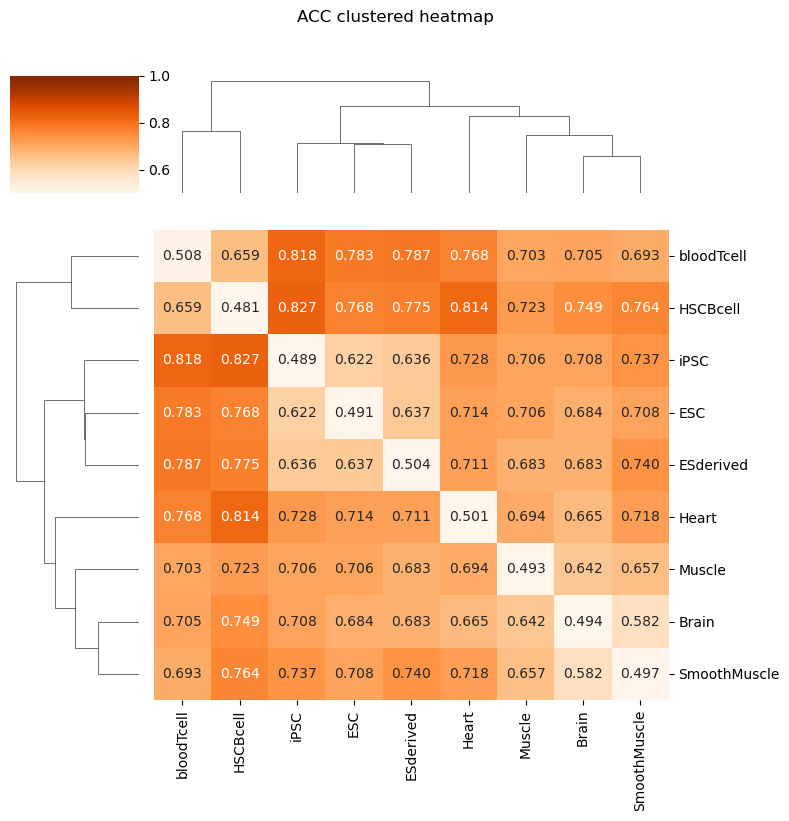

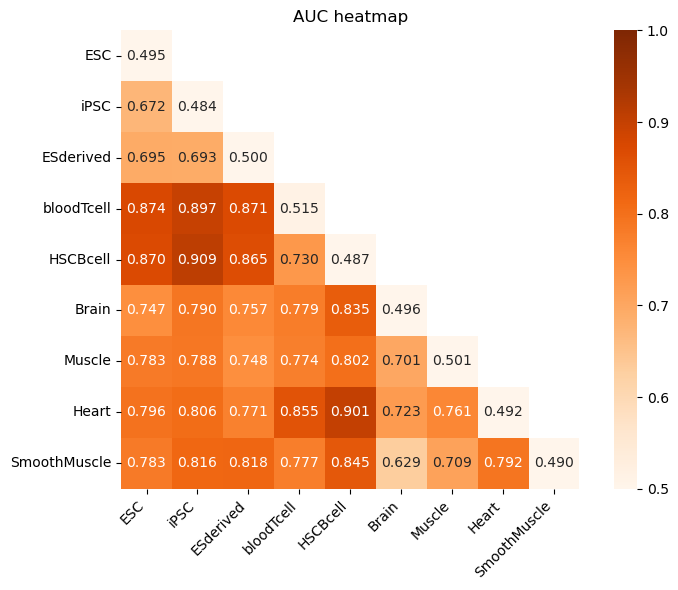

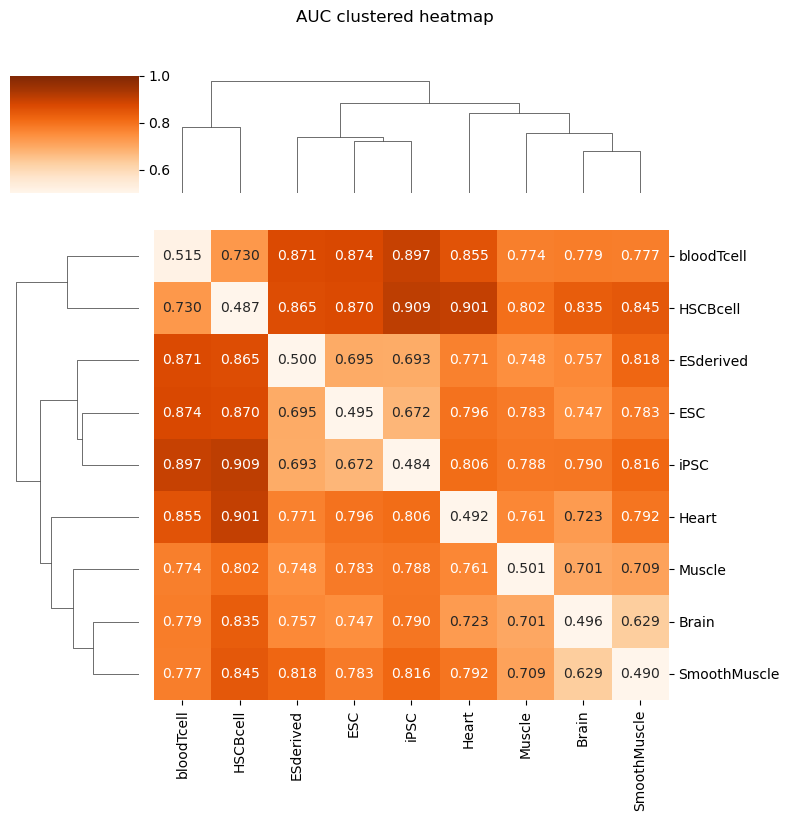

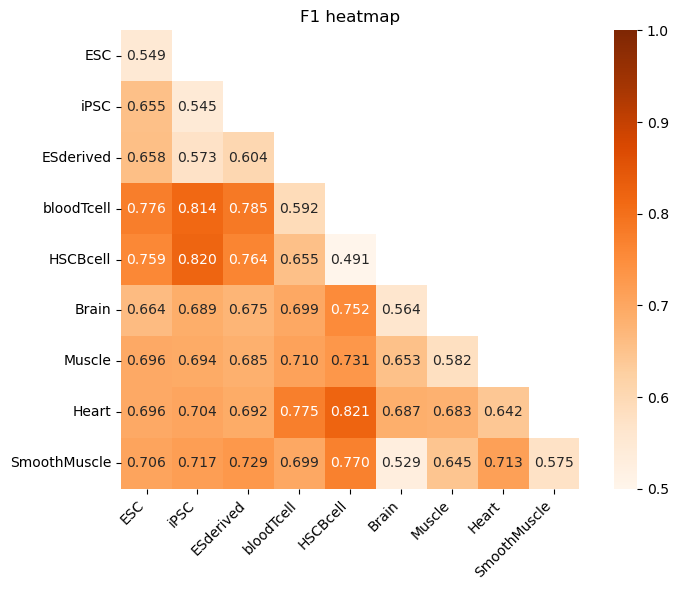

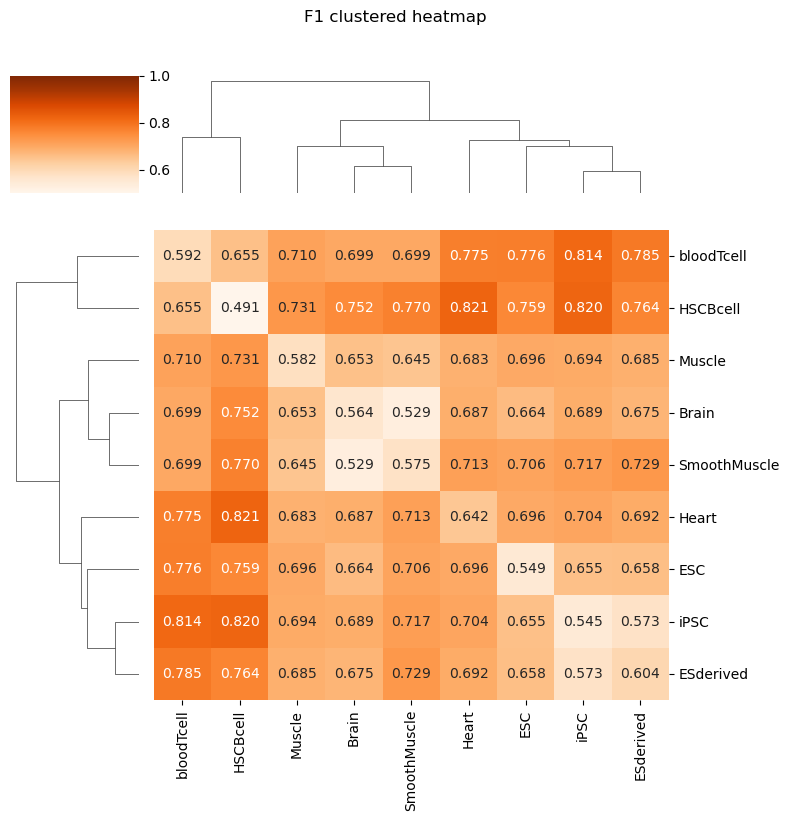

In [16]:
metrics = ["ACC", "AUC", "F1"]
for metric in metrics:
    # Build the matrix (same as before)
    mat = pd.DataFrame(index=samples, columns=samples, dtype=float)
    for _, row in df.iterrows():
        mat.loc[row["A"], row["B"]] = row[metric]
        mat.loc[row["B"], row["A"]] = row[metric]

    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    mat_masked = mat.mask(mask)

    # ==== NON-CLUSTER heatmap ====
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        mat_masked.astype(float),
        annot=True,
        fmt=".3f",
        cmap="Oranges",
        square=True,
        mask=mask,
        cbar=True,
        vmin=0.5,
        vmax=1.0,
        ax=ax,
    )

    # Rotate x-axis labels 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f"{metric} heatmap")
    fig.tight_layout()

    # 1) SAVE FIRST
    fig.savefig(outdir / f"{metric}_heatmap.pdf", format="pdf", dpi=300)

    # 2) THEN SHOW IN NOTEBOOK
    plt.show()

    plt.close(fig)

    # ==== CLUSTERED heatmap (as before) ====
    cluster = sns.clustermap(
        mat.astype(float),
        cmap="Oranges",
        annot=True,
        fmt=".3f",
        cbar=True,
        vmin=0.5,
        vmax=1.0,
        figsize=(8, 8),
        method="average",
        metric="euclidean",
    )
    
    cluster.fig.suptitle(f"{metric} clustered heatmap", y=1.02)
    cluster.fig.tight_layout()
    plt.show()

    cluster.savefig(outdir / f"{metric}_heatmap_clustered.pdf",
                    format="pdf", dpi=300)
    plt.close(cluster.fig)


In [28]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import leaves_list, linkage, ClusterWarning

import pandas as pd

# Make sure the custom module is visible
# sys.path.append("/work3/Users/oba/references/chromBERT/stem_change/src")
import css_utility_rnakato as crb


def heatmap_DTW(input_path, output_path="./motif_dtw.pdf", n_clusters=11):
    """
    Compute the DTW distance matrix via crb.motif_init2pred,
    reorder by hierarchical clustering, and save a heatmap.
    """
    dtw_distance_matrix, y_pred = crb.motif_init2pred(
        input_path=input_path,
        categorical=False,
        fillna_method="ffill",
        n_clusters=n_clusters,
        linkage_method="complete",
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ClusterWarning)
        linkage_matrix = linkage(dtw_distance_matrix, method="complete")
        ordered_indices = leaves_list(linkage_matrix)
        reordered_matrix = dtw_distance_matrix[ordered_indices][:, ordered_indices]

    plt.figure(figsize=(6, 5))
    sns.heatmap(reordered_matrix, cmap="viridis", square=True)
    plt.title("Cluster-Reordered DTW Distance Matrix")
    plt.xlabel("Motif index (reordered)")
    plt.ylabel("Motif index (reordered)")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()
    plt.close()

    return y_pred, dtw_distance_matrix


def run_motif_clustering(input_csv, output_dir):
    """
    Run the full motif clustering pipeline in a notebook:

      1. Dendrogram + clustering (uses motif_init2pred_with_dendrogram as-is)
      2. UMAP visualization
      3. Cluster visualization
      4. DTW distance heatmap

    Without modifying crb.motif_init2pred_with_dendrogram.
    """
    input_csv = Path(input_csv)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1) Dendrogram + clustering
    #    We call the function as-is and then capture the current figure.
    y_pred = crb.motif_init2pred_with_dendrogram(
        input_path=input_csv,
        categorical=False,
        fillna_method="ffill",
        linkage_method="complete",
        threshold=35,
    )

    # Save the dendrogram figure that was just shown
    dendro_fig = plt.gcf()
    dendro_fig.savefig(output_dir / "motif_dendrogram.pdf", dpi=300, bbox_inches="tight")
    plt.close(dendro_fig)

    n_clusters = len(set(y_pred))

    # Draw UMAP using the original function (no saving inside)
    crb.motif_init2umap(
        input_path=input_csv,
        categorical=False,
        n_clusters=n_clusters,
        fillna_method="ffill",
        linkage_method="complete",
        n_neighbors=5,
        min_dist=0.3,
        random_state=2,
    )

    # Immediately capture the figure and save it
    umap_fig = plt.gcf()
    umap_fig.savefig(output_dir / "motif_umap.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(umap_fig)

    # 3) Cluster visualization (draws on current figure)
    crb.motif_init2cluster_vis(
        input_path=input_csv,
        categorical=False,
        n_clusters=n_clusters,
        fillna_method="ffill",
        linkage_method="complete",
        random_state=2,
        font_scale=0.0035,
        font_v_scale=10,
        fig_w=12,
        fig_h=8,
        node_size=1000,
        node_dist=0.05,
    )

    # Capture the current figure
    cluster_fig = plt.gcf()

    # Save to YOUR output filename
    cluster_fig.savefig(output_dir / "motif_cluster.pdf",
                        dpi=300,
                        bbox_inches="tight")

    plt.show()
    plt.close(cluster_fig)
    print(f"All motif clustering figures saved under: {output_dir}")


DTW computation time: 0.8329 seconds


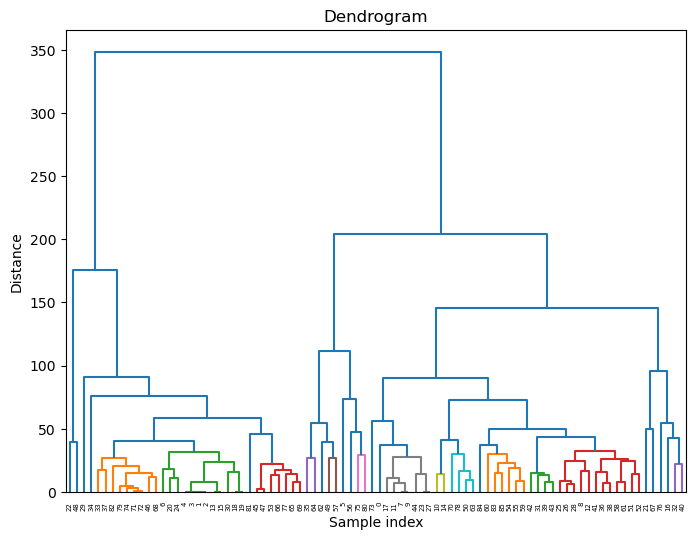

Estimated number of clusters: 28
Clustering Duration: 0:00:00.098978
Number of cluster estimated by dendrogram with designated threshold 35: [28] clusters
Min distance: 0.0
Max distance: 54.22176684690383
Median distance: 19.79898987322333
DTW computation time: 0.7662138938903809 seconds
Clustering Duration: 0:00:00.000536


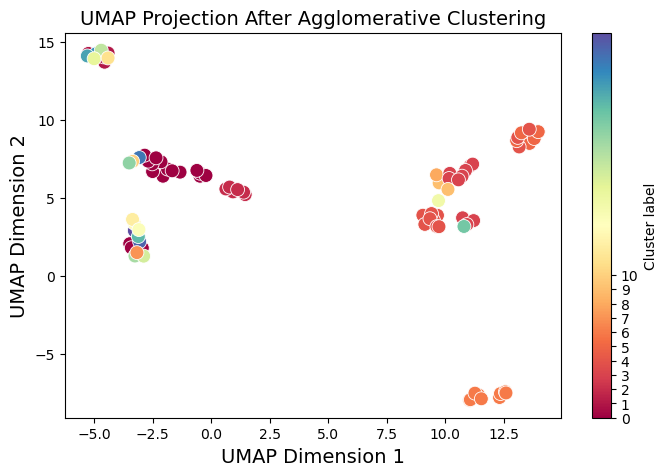

<Figure size 640x480 with 0 Axes>

DTW computation time: 0.7495110034942627 seconds
Clustering Duration: 0:00:00.000493
28


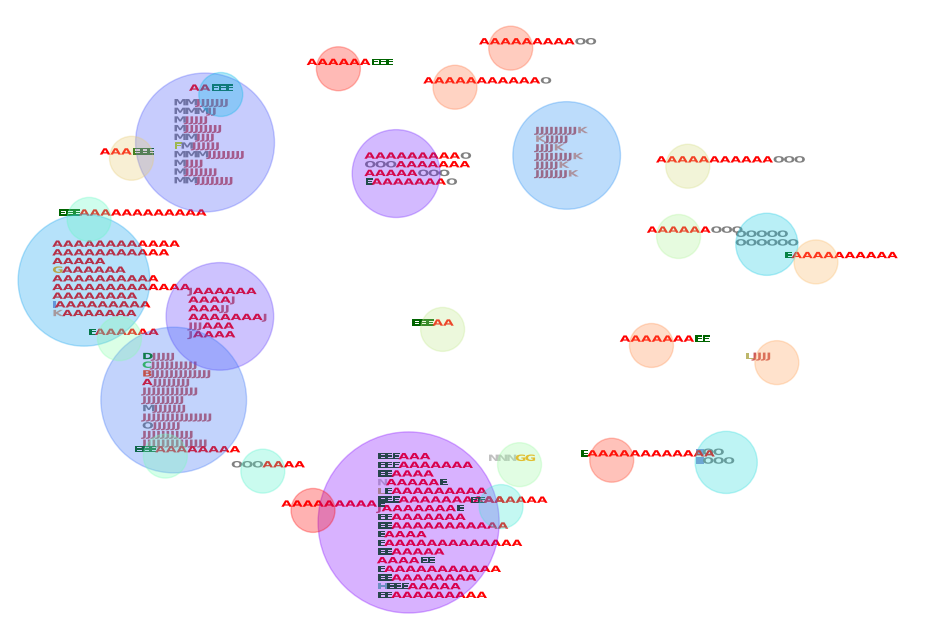

<Figure size 640x480 with 0 Axes>

All motif clustering figures saved under: Revision_code/Fig7b


In [29]:
input_csv = "./Revision_code/Fig7b/init_df.csv"
output_dir = "./Revision_code/Fig7b/"

run_motif_clustering(input_csv, output_dir)


In [31]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, ClusterWarning
from umap import UMAP

import css_utility_rnakato as crb


def run_motif_clustering(
    input_csv,
    output_dir,
    n_clusters=11,
    linkage_method="complete",
    threshold=35,
    random_state=2,
):
    """
    Notebook-friendly pipeline for Fig. 7B-like motif clustering.

    Steps:
      1. Compute DTW distance matrix + cluster labels via crb.motif_init2pred
      2. Dendrogram from DTW matrix          -> motif_dendrogram.pdf
      3. DTW distance heatmap (reordered)    -> motif_dtw.pdf
      4. UMAP embedding colored by clusters  -> motif_umap.pdf
      5. Motif cluster-graph via crb.motif_init2cluster_vis
         (uses its own internal save, then we rename cluster_result.pdf -> motif_cluster.pdf)
    """

    input_csv = Path(input_csv)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # -------------------------------------------------------
    # 1) DTW distance matrix + cluster labels
    # -------------------------------------------------------
    print("Computing DTW distance matrix and cluster labels...")
    dtw_distance_matrix, y_pred = crb.motif_init2pred(
        input_path=input_csv,
        categorical=False,
        fillna_method="ffill",
        n_clusters=n_clusters,
        linkage_method=linkage_method,
    )
    y_pred = np.asarray(y_pred)
    print(f"Number of clusters (n_clusters): {n_clusters}")

    # -------------------------------------------------------
    # 2) Dendrogram
    # -------------------------------------------------------
    print("Plotting dendrogram...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ClusterWarning)
        Z = linkage(dtw_distance_matrix, method=linkage_method)

    plt.figure(figsize=(8, 6))
    dendrogram(Z, color_threshold=threshold)
    plt.title("Dendrogram")
    plt.xlabel("Motif index")
    plt.ylabel("Distance")
    plt.tight_layout()
    dendro_path = output_dir / "motif_dendrogram.pdf"
    plt.savefig(dendro_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  -> saved {dendro_path}")

    # -------------------------------------------------------
    # 3) DTW heatmap (reordered)
    # -------------------------------------------------------
    print("Plotting DTW distance heatmap...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ClusterWarning)
        Z2 = linkage(dtw_distance_matrix, method=linkage_method)
        order = leaves_list(Z2)

    reordered = dtw_distance_matrix[order][:, order]

    plt.figure(figsize=(6, 5))
    sns.heatmap(reordered, cmap="viridis", square=True)
    plt.title("Cluster-Reordered DTW Distance Matrix")
    plt.xlabel("Motif index (reordered)")
    plt.ylabel("Motif index (reordered)")
    plt.tight_layout()
    dtw_path = output_dir / "motif_dtw.pdf"
    plt.savefig(dtw_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  -> saved {dtw_path}")

    # -------------------------------------------------------
    # 4) UMAP on DTW matrix
    # -------------------------------------------------------
    print("Computing UMAP embedding...")
    reducer = UMAP(
        n_neighbors=5,
        min_dist=0.3,
        random_state=random_state,
        n_jobs=1,
    )
    embedding = reducer.fit_transform(dtw_distance_matrix)

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_pred,
        cmap="Spectral",
        s=100,
        edgecolors="white",
        linewidth=0.6,
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster label")
    plt.title("UMAP Projection After Agglomerative Clustering")
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
    plt.tight_layout()
    umap_path = output_dir / "motif_umap.pdf"
    plt.savefig(umap_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  -> saved {umap_path}")

    # -------------------------------------------------------
    # 5) Motif cluster visualization (uses crb.motif_init2cluster_vis)
    # -------------------------------------------------------
    print("Drawing motif cluster graph via crb.motif_init2cluster_vis...")
    # This function internally:
    #   - computes clusters again
    #   - draws a networkx layout with text patches
    #   - shows the figure
    #   - saves to ./cluster_result.pdf in the current working directory
    crb.motif_init2cluster_vis(
        input_path=input_csv,
        categorical=False,
        n_clusters=n_clusters,
        fillna_method="ffill",
        linkage_method=linkage_method,
        random_state=random_state,
        font_scale=0.0035,
        font_v_scale=10,
        fig_w=12,
        fig_h=8,
        node_size=1000,
        node_dist=0.05,
    )

    # The function above saves ./cluster_result.pdf.
    # Move/rename it into output_dir as motif_cluster.pdf.
    cluster_src = Path("./cluster_result.pdf")
    cluster_dst = output_dir / "motif_cluster.pdf"
    if cluster_src.exists():
        cluster_src.replace(cluster_dst)
        print(f"  -> saved {cluster_dst}")
    else:
        print("  !! Warning: cluster_result.pdf not found; "
              "motif_init2cluster_vis may not have saved it as expected.")

    print(f"\nAll motif clustering figures saved under: {output_dir}")


Computing DTW distance matrix and cluster labels...
DTW computation time: 0.7933859825134277 seconds
Clustering Duration: 0:00:00.000472
Number of clusters (n_clusters): 11
Plotting dendrogram...


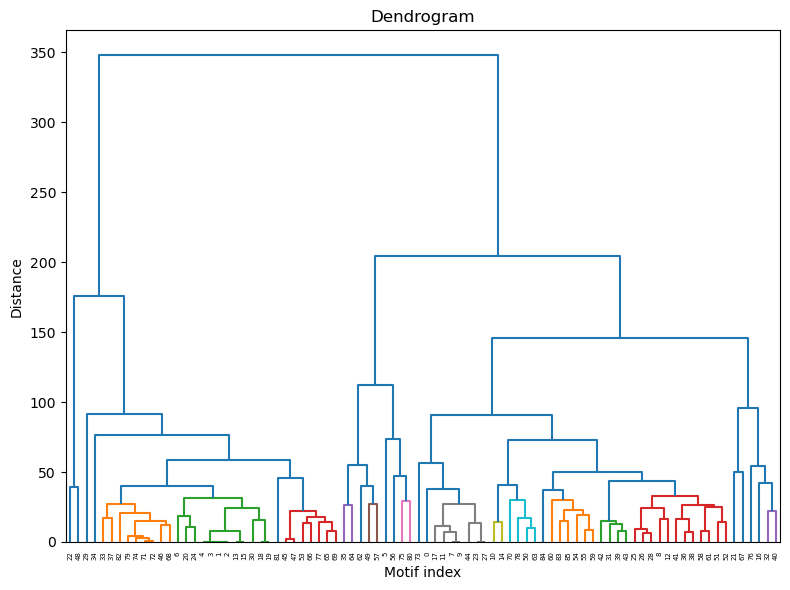

  -> saved Revision_code/Fig7b/plots/motif_dendrogram.pdf
Plotting DTW distance heatmap...


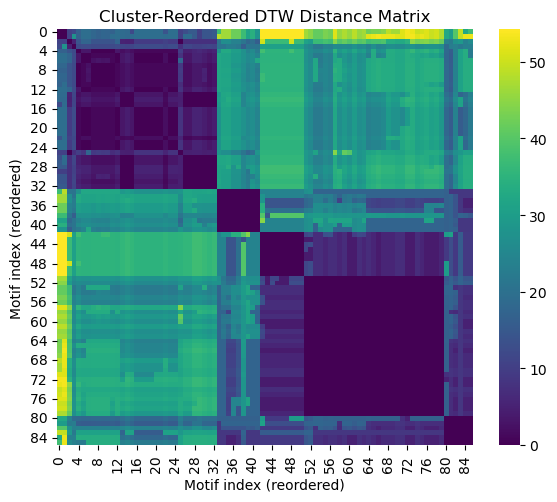

  -> saved Revision_code/Fig7b/plots/motif_dtw.pdf
Computing UMAP embedding...


/Users/schona/miniconda3/envs/chrombert/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


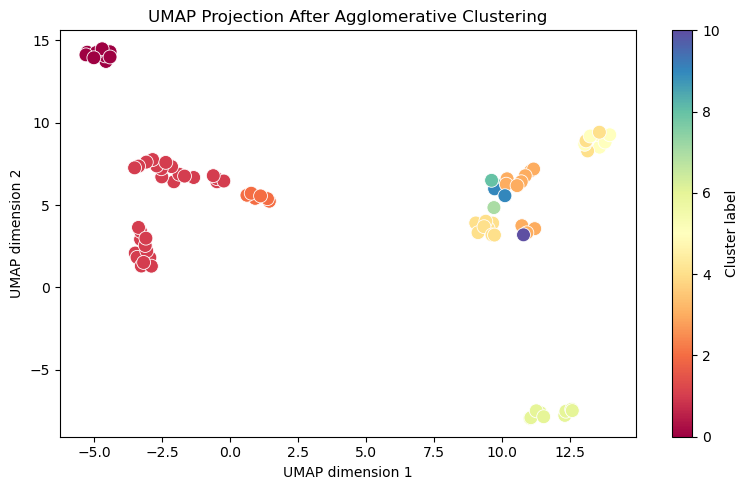

  -> saved Revision_code/Fig7b/plots/motif_umap.pdf
Drawing motif cluster graph via crb.motif_init2cluster_vis...
DTW computation time: 0.7662432193756104 seconds
Clustering Duration: 0:00:00.000688
11


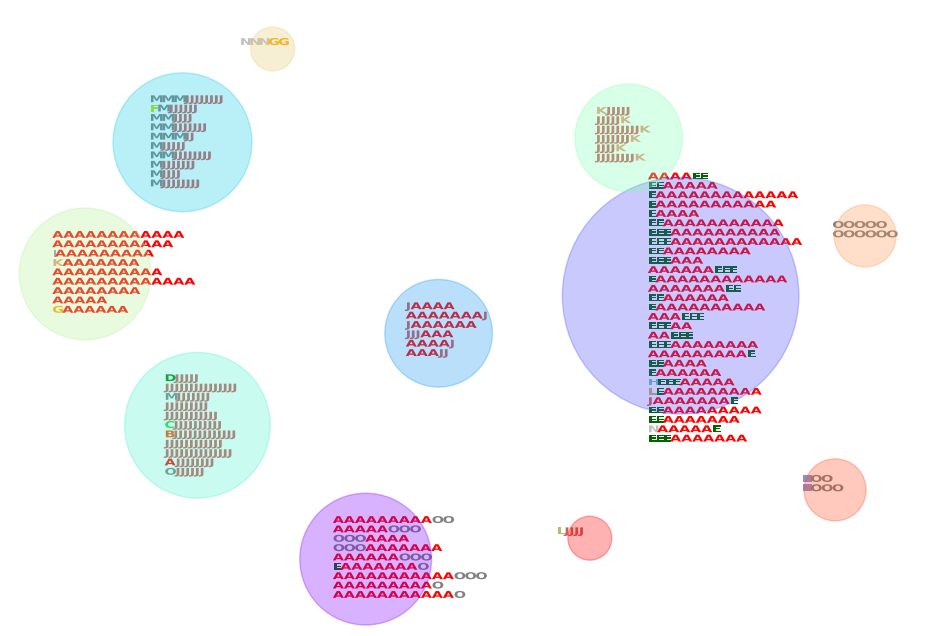

  -> saved Revision_code/Fig7b/plots/motif_cluster.pdf

All motif clustering figures saved under: Revision_code/Fig7b/plots


In [33]:
input_csv = "./Revision_code/Fig7b/init_df.csv"
output_dir = "./Revision_code/Fig7b/plots"
run_motif_clustering(input_csv, output_dir)